The [TensorFlow Embedding Projector](https://projector.tensorflow.org/) places
high-dimensional word vectors in a three-dimensional map where distance approximates
semantic similarity, and lets you pick a word to see its nearest neighbors. In this
assignment you build the same thing in PyTorch: you train word embeddings with
`torch.nn.Embedding`, project them to three dimensions, draw an interactive scatter, and
query the neighborhood of any token.

You will complete the parts marked with `TODO(you)`. Each raises `NotImplementedError`
until you implement it.

In [3]:
import re
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

## Corpus and vocabulary

Word embeddings are learned from co-occurrence in text. Load a compact corpus, keep the
most frequent words as the vocabulary, and turn the text into a stream of integer ids.

In [4]:
from datasets import load_dataset

raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
text = " ".join(raw["text"]).lower()
tokens = re.findall(r"[a-z]+", text)[:300_000]
counts = Counter(tokens)

V = 8000
# TODO(you): build `vocab` (the V most common words), `word2idx`, `idx2word`,
# and `corpus` (the token stream mapped to ids, dropping out-of-vocabulary words).

vocab = [word for word, _ in counts.most_common(V)]

word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: word for i, word in enumerate(vocab)}

# map tokens to ids, dropping OOV words
corpus = [word2idx[word] for word in tokens if word in word2idx]

#raise NotImplementedError("Build the vocabulary and the integer-encoded corpus.")

/home/steve/Desktop/SUMMER2026/CS375/eng-ai-agents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Word2vec embeddings with softmax and cross-entropy

A word2vec model learns word embeddings by predicting context words. This is the skip-gram
architecture of word2vec: the center word predicts its context. The center word's embedding is
scored against every word in the vocabulary, a softmax turns those scores into a probability
distribution over possible context words, and the cross-entropy loss pushes up the probability
of the true context word:

$$p(o \mid c) = \frac{\exp(\mathbf{c}\cdot\mathbf{v}_o)}{\sum_{w}\exp(\mathbf{c}\cdot\mathbf{v}_w)},
\qquad L = -\log p(o \mid c).$$

The learned center embedding table is the word-vector matrix you will project.

In [5]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.center = nn.Embedding(vocab_size, dim)   # word vectors
        self.output = nn.Linear(dim, vocab_size)      # score every word as a possible context
        nn.init.uniform_(self.center.weight, -0.5 / dim, 0.5 / dim)

    def forward(self, center_ids):
        # TODO(you): embed the center ids and return the (B, V) scores over the whole
        # vocabulary (one score per possible context word). Cross-entropy + softmax are applied
        # by the loss in the training loop, so return the raw scores (logits), not probabilities.

        x = self.center(center_ids)   # (B, dim)
        logits = self.output(x)       # (B, V)
        return logits
        #raise NotImplementedError("Return the vocabulary-sized scores for each center word.")

In [6]:
# Build (center, context) pairs from a sliding window
window = 3
pairs = []
for i, wc in enumerate(corpus):
    for j in range(max(0, i - window), min(len(corpus), i + window + 1)):
        if j != i:
            pairs.append((wc, corpus[j]))
pairs = np.array(pairs, dtype=np.int64)

dim, B, epochs = 64, 1024, 3
model = Word2Vec(V, dim)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss()

# TODO(you): write the training loop. For each mini-batch, get the (B, V) logits from the center
# ids with model(...), compute the cross-entropy loss against the true context ids with loss_fn,
# backprop, and step the optimizer. Track the per-epoch loss. After training, set
# `emb = model.center.weight.detach().cpu().numpy()`.

dim, B, epochs = 64, 1024, 3
model = Word2Vec(V, dim)

opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(epochs):

    perm = np.random.permutation(len(pairs))
    epoch_loss = 0.0
    batches = 0

    for start in range(0, len(pairs), B):

        batch_idx = perm[start:start + B]
        batch = pairs[batch_idx]

        center_ids = torch.tensor(batch[:, 0], dtype=torch.long)
        context_ids = torch.tensor(batch[:, 1], dtype=torch.long)

        opt.zero_grad()

        logits = model(center_ids)          # (B, V)
        loss = loss_fn(logits, context_ids)

        loss.backward()
        opt.step()

        epoch_loss += loss.item()
        batches += 1

    print(f"Epoch {epoch + 1}: loss = {epoch_loss / batches:.4f}")

emb = model.center.weight.detach().cpu().numpy()
#raise NotImplementedError("Train the word2vec model with cross-entropy and set `emb`.")

Epoch 1: loss = 6.9848
Epoch 2: loss = 6.7106
Epoch 3: loss = 6.5735


## Projecting the embeddings to three dimensions

The embedding matrix lives in $d=64$ dimensions. To see it, project a few thousand of the most
frequent words down to three dimensions. Principal component analysis is linear and fast; UMAP is
nonlinear and tends to separate clusters more sharply. The interactive scatter lets you rotate the
cloud and hover to read each word.

In [7]:
from sklearn.decomposition import PCA

N = 1500
plot_words = vocab[:N]
X = emb[:N]

# TODO(you): compute `pca3` (N x 3) with PCA, and `umap3` with UMAP (guard UMAP in a
# try/except so a missing umap-learn does not crash the notebook).
from sklearn.decomposition import PCA

N = 1500
plot_words = vocab[:N]
X = emb[:N]

# PCA projection
pca = PCA(n_components=3)
pca3 = pca.fit_transform(X)

#raise NotImplementedError("Project the embeddings to 3D with PCA (and UMAP).")

In [8]:
import plotly.graph_objects as go

# TODO(you): write `plot_embeddings(coords, words, query=None, neighbor_set=None)` that
# draws a plotly Scatter3d: hover text = the word; color/size the `query` and any words in
# `neighbor_set` distinctly. Return the figure (end the cell with the figure object).
import plotly.graph_objects as go

def plot_embeddings(coords, words, query=None, neighbor_set=None):

    colors = []
    sizes = []

    for word in words:

        if query is not None and word == query:
            colors.append("red")
            sizes.append(10)

        elif neighbor_set is not None and word in neighbor_set:
            colors.append("orange")
            sizes.append(7)

        else:
            colors.append("blue")
            sizes.append(4)

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=coords[:, 0],
                y=coords[:, 1],
                z=coords[:, 2],
                mode="markers",
                text=words,
                hovertext=words,
                hoverinfo="text",
                marker=dict(
                    size=sizes,
                    color=colors
                )
            )
        ]
    )

    fig.update_layout(
        title="Word Embeddings",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z"
        ),
        height=700
    )

    return fig
#raise NotImplementedError("Build the interactive 3D plotly scatter helper, then call it on pca3.")

## Querying a token's neighborhood

The projector's key feature is the neighborhood query: pick a word and see its closest
words. Closeness is measured by cosine similarity in the full embedding space (not in the
3D projection). The query below returns the top-k neighbors and highlights them in the
scatter.

In [9]:
def neighbors(word, k=10):
    # TODO(you): return the k nearest words to `word` by cosine similarity over `emb`,
    # as a list of (word, score) sorted by descending score, excluding `word` itself.
    #raise NotImplementedError("Implement the cosine-similarity k-nearest-neighbor query.")
    if word not in word2idx:
        return []

    idx = word2idx[word]

    query_vec = emb[idx]

    query_norm = np.linalg.norm(query_vec)

    emb_norms = np.linalg.norm(emb, axis=1)

    sims = emb @ query_vec / (emb_norms * query_norm)

    sims[idx] = -1  # exclude the query word itself

    top_idx = np.argsort(sims)[-k:][::-1]

    return [(idx2word[i], sims[i]) for i in top_idx]


for w, s in neighbors("government", 10):
    print(f"{w:15s} {s:.3f}")

fledgling       0.853
occupying       0.828
commissioner    0.825
subcontinent    0.822
invasion        0.811
nazi            0.810
wartime         0.808
municipal       0.805
empire          0.804
committee       0.803


In [10]:
# TODO(you): pick a query word, get its neighbors with neighbors(query, 10), and re-draw the
# projector with plot_embeddings(...) highlighting the query and its neighbors. A word only
# appears in the plot if it is among the N most frequent words used for pca3.
#raise NotImplementedError("Re-draw the projector highlighting a query word and its neighbors.")
query = "government"

nbrs = neighbors(query, 10)

neighbor_set = {w for w, _ in nbrs}

fig = plot_embeddings(
    pca3,
    plot_words,
    query=query,
    neighbor_set=neighbor_set
)

fig

## Exploration

Answer in the cells you add below.

1. Query several words of your choice (a few nouns, a verb, a function word). Which return clean
   semantic neighbors and which do not? Why might rare words give noisier neighbors?
2. Plot the clusters. Draw the projected embeddings (the UMAP layout separates clusters most
   clearly) and describe the groupings you see: do related words land near each other? Name a few
   clusters you can identify.

1:  The noun government, model returned meaningful semantic neighbors such as municipal, commissioner, committee, commonwealth, and infrastructure which are related to government, and politics indicating that the model learned useful semantic relationships.

The noun computer, the neighbors included words such as distinctive, nonsense, quote, and claim which suggest that the model did not learn a strong semantic representation for the word computer.

The verb run neighbors included the words losing, goaltender, roster and defeat which appear to come from sports related context. The model associated the word run with specific contexts in the training corpus rather than the general meaning.

The function word the, the neighbors were unrelated words which was expected as function words occur in many different contexts and carry less semantic information.

Overall, government produced the appropriate semantic neighbors, while computer and the produced noisier results. Rare words give noisier neighbors because they appear fewer times in the training corpus which gives the model less information to learn accurate embeddings.



In [24]:
for w in ["government", "computer", "run", "the"]:
    print("\n", w)
    for n, s in neighbors(w, 10):
        print(f"{n:15s} {s:.3f}")


 government
municipal       0.825
pakistani       0.823
commissioner    0.817
enforcement     0.809
committee       0.806
fledgling       0.804
encountered     0.803
commonwealth    0.802
junta           0.797
infrastructure  0.794

 computer
distinctive     0.826
nonsense        0.823
quote           0.814
remember        0.812
claim           0.811
indeed          0.811
copy            0.809
treat           0.806
serious         0.804
assume          0.801

 run
equalised       0.791
cheltenham      0.788
losing          0.770
goaltender      0.769
carson          0.767
fleetwood       0.762
successive      0.761
before          0.757
roster          0.754
defeat          0.752

 the
schooling       0.749
melodrama       0.736
genesis         0.732
tenth           0.732
richest         0.728
cuautla         0.720
tolerance       0.717
astronomical    0.715
slope           0.715
polymer         0.713


In [21]:
from collections import Counter

counts = Counter(corpus)

print(counts["government"])
print(counts["aardvark"])

0
0


2:UMAP projection produces one large dense cluster with most of the vocabulary with a few isolated outliers. The word labels government, run, the, and computer were isolated in different regions of the embedding space although the visualization did not show clear separated semantic clusters. 

The nearest neighbor results suggest that the model learned semantic relationships , such as examples like the word government was located near the word municipal, commissioner , committee, and commonwealth which are related to politics or public administration. Other words such as computer produced less coherent neighbors which indicates that the embeddings are not uniformly strong across the vocabulary. 

Overall, the UMAP visualization suggests that the model captured some semantic structure and not the clusters sharply separated which would have additional trained epochs, have a larger embedding dimension or a larger corpus would likely produce distinct semantic groupings. 


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



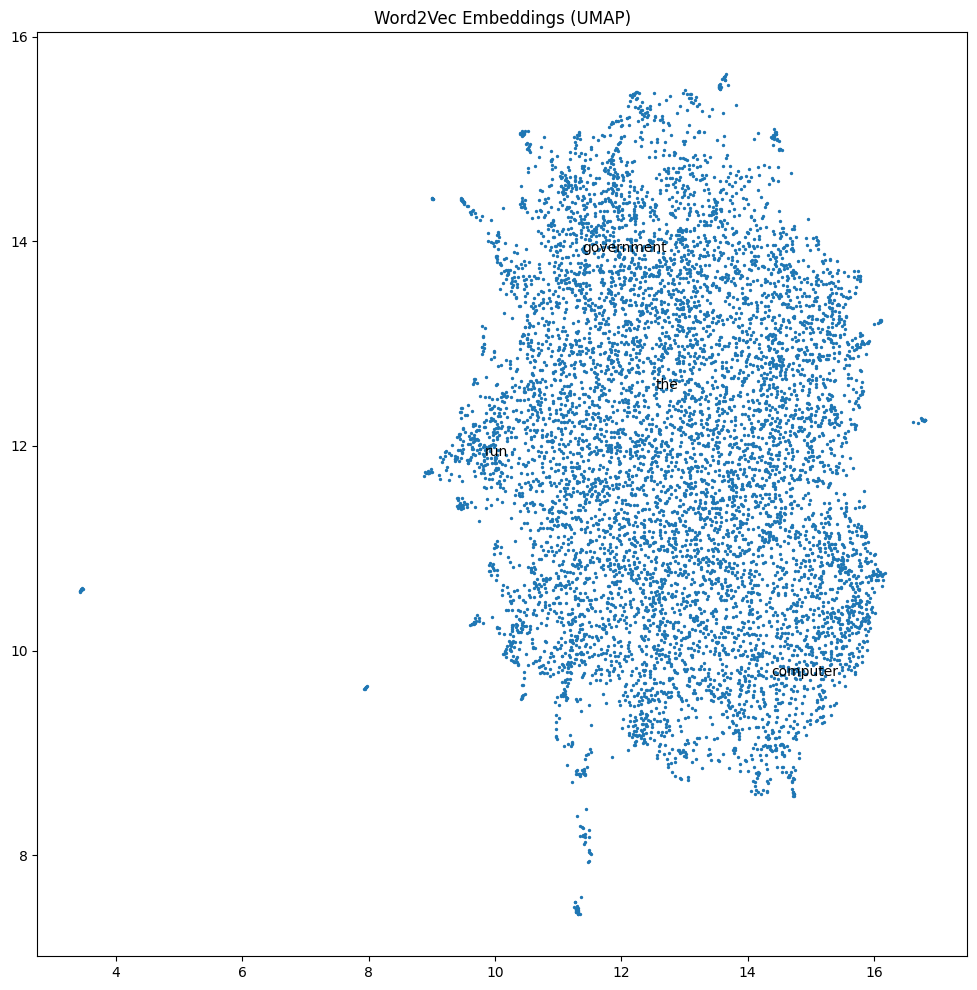

In [25]:
import umap
import matplotlib.pyplot as plt

# Reduce embeddings to 2 dimensions
proj = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(emb)

# Plot all words
plt.figure(figsize=(12, 12))
plt.scatter(proj[:, 0], proj[:, 1], s=2)

# Words to label
words_to_show = [
    "government",
    "computer",
    "run",
    "the"
]

# Add labels
for w in words_to_show:

    if w in word2idx:

        idx = word2idx[w]

        plt.text(
            proj[idx, 0],
            proj[idx, 1],
            w,
            fontsize=10
        )

plt.title("Word2Vec Embeddings (UMAP)")
plt.show()